In [15]:
!pip install scikit-learn


   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.7 MB 683.2 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/8.7 MB 683.2 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/8.7 MB 683.2 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/8.7 MB 487.5 kB/s eta 0:00:17
   --- ------------------------------------ 0.8/8.7 MB 487.5 kB/s eta 0:00:17
   ---- ----------------------------------- 1.0/8.7 MB 525.3 kB/s eta 0:00:15
   ---- ----------------------------------- 1.0/8.7 MB 525.3 kB/s eta 0:00:15
   ------ --------------------------------- 1.3/8.7 MB 552.5 kB/s eta 0:00:14
   ------ --------------------------------- 1.3/8.7 MB 552.5 kB/s eta 0:00:14
   ------ ------------

In [16]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [2]:
image_path = '../output/player_crop.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  

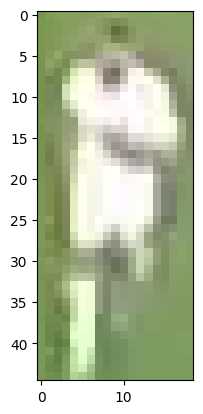

In [4]:
plt.imshow(image)
plt.show()

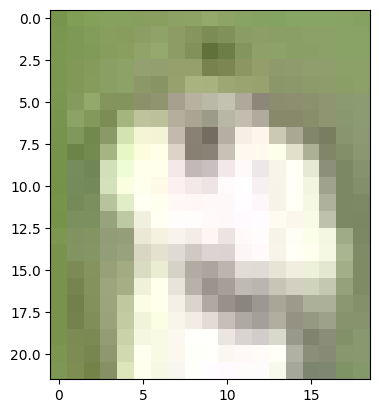

In [5]:
top_half = image[0:image.shape[0]//2, :]
plt.imshow(top_half)
plt.show()

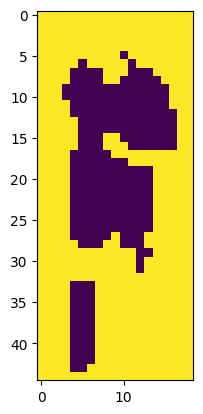

In [19]:
image_2d = image.reshape((-1, 3))

kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

labels = kmeans.labels_

clustered_image = labels.reshape(image.shape[0], image.shape[1])

plt.imshow(clustered_image)
plt.show()

In [20]:
corner_clusters = [ clustered_image[0,0], clustered_image[0,-1], clustered_image[-1,0], clustered_image[-1,-1] ]

non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)

print("Non-player cluster label:", non_player_cluster)

Non-player cluster label: 1


In [21]:
player_cluster = 1 - non_player_cluster
print("Player cluster label:", player_cluster)

Player cluster label: 0


In [ ]:
kmeans.kluster_centers_[player_cluster]